<a href="https://colab.research.google.com/github/Lobnaait/SEARCH_Lobna_Tsetline_CMRI/blob/main/Copia_di_Tsetline_ACDCdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from huggingface_hub import snapshot_download
data_dir = snapshot_download(repo_id="mathpluscode/ACDC", allow_patterns=["*.nii.gz", "*.csv"], repo_type="dataset")
# https://huggingface.co/datasets/mathpluscode/ACDC

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 752 files:   0%|          | 0/752 [00:00<?, ?it/s]

In [21]:
!ls /root/.cache/huggingface/hub/datasets--mathpluscode--ACDC/snapshots/4a312b610f395eda5dc0aa36f087dd6ca9991e41/

test  test.csv	train  train.csv


In [22]:
!pip install pyTsetlinMachine

In [23]:
#IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, classification_report, confusion_matrix
from pyTsetlinMachine.tm import MultiClassTsetlinMachine

In [24]:
#EXTRACT DATASET
import os

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(train.shape)
print(test.shape)

train.head(10)

(100, 15)
(50, 15)


,pid,pathology,height,weight,bmi,n_frames,ed_frame,es_frame,original_sax_spacing_x,original_sax_spacing_y,original_sax_spacing_z,n_slices,edv,esv,ef
0,patient001,DCM,1.84,95.0,28.060019,30,1,12,1.562500,1.562500,10.0,10,1354.58,1125.97,16.876818
1,patient002,DCM,1.60,70.0,27.343750,30,1,12,1.367188,1.367188,10.0,10,1212.69,979.53,19.226678
2,patient003,DCM,1.65,77.0,28.282828,30,1,15,1.562500,1.562500,10.0,10,1405.42,1298.96,7.574960
3,patient004,DCM,1.59,46.0,18.195483,28,1,15,1.367188,1.367188,10.0,10,1226.58,1114.83,9.110698
4,patient005,DCM,1.65,77.0,28.282828,30,1,13,1.406250,1.406250,10.0,10,1446.55,1211.36,16.258684
5,patient006,DCM,1.80,70.0,21.604938,28,1,16,1.757812,1.757812,10.0,11,1637.74,1374.18,16.092909
6,patient007,DCM,1.73,107.0,35.751278,16,1,7,1.875000,1.875000,10.0,10,1589.67,1411.75,11.192260
7,patient008,DCM,1.80,100.0,30.864198,28,1,13,1.562500,1.562500,10.0,10,1332.23,1158.90,13.010516
8,patient009,DCM,1.53,61.0,26.058354,35,1,13,1.367190,1.367190,10.0,10,1254.25,1154.37,7.963325
9,patient010,DCM,1.70,68.0,23.529412,28,1,13,1.562500,1.562500,10.0,10,1484.35,1316.59,11.301917


In [25]:
TARGET = "pathology"
print(train[TARGET].value_counts())


pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [26]:
# EXTRACT TRAININNG SET AND VALIDATION SET
features = ['height',	'weight',	'bmi',	'n_frames',	'ed_frame',	'es_frame',	'original_sax_spacing_x',	'original_sax_spacing_y',	'original_sax_spacing_z',	'n_slices', 'edv', 'esv', 'ef']

print("\n ")
X = train[features].copy()
y = train[TARGET].copy()

print("X_train shape:", X.shape)
print("y_train shape:", y.shape)
print("\nClasses:", y.value_counts())


 
X_train shape: (100, 13)
y_train shape: (100,)

Classes: pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [27]:
# EXTRACT TEST SET
X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nClasses:", y_test.value_counts())


X_test shape: (50, 13)
y_test shape: (50,)

Classes: pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10
Name: count, dtype: int64


In [28]:
def compute_thresholds(X, n_thresholds):
  percentile_values = np.linspace(0, 100, int(n_thresholds) + 2)[1:-1] # Exclude 0 and 100
  thresholds = []
  for feature_index in range(X.shape[1]):
      feature_thresholds = np.percentile(X[:, feature_index], percentile_values)
      feature_thresholds = np.unique(feature_thresholds) # Remove duplicate thresholds
      thresholds.append(feature_thresholds)
  return thresholds

In [29]:
# ---------------------------------------------------------
# Convert continuous features into binary features
# ---------------------------------------------------------
import numpy as np

def threshold_binarize(X, thresholds):
    binary_features = []

    for feature_index in range(X.shape[1]):
        for threshold in thresholds[feature_index]:
            binary_features.append( (X[:, feature_index] >= threshold).astype(np.uint32) )

    return np.array(binary_features).T

In [30]:
# Reproducible split
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Convert pandas dataframes to NumPy
X_train_np = X_train.to_numpy(dtype=np.float32)
X_validation_np = X_validation.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

# Encode class labels as integers
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_validation_enc = label_encoder.transform(y_validation)
y_test_enc = label_encoder.transform(y_test)

In [31]:
# ---------------------------------------------------------
# Find optimal number of thresholds
# ---------------------------------------------------------

threshold_candidates = range(1, 21)

results = []

for n_thresholds in threshold_candidates:
    #print("=" * 60)
    #print(f"Testing n_thresholds = {n_thresholds}")

    # IMPORTANT:
    # thresholds are calculated ONLY from training data
    thresholds = compute_thresholds(X_train_np, n_thresholds)

    # Apply exactly the same thresholds to train and validation
    X_train_bin = threshold_binarize( X_train_np, thresholds)
    X_validation_bin = threshold_binarize( X_validation_np, thresholds)

    # Tsetlin Machine
    tm = MultiClassTsetlinMachine(number_of_clauses=1000, T=50, s=5.0)
    tm.fit(X_train_bin, y_train_enc, epochs=100)
    predictions = tm.predict(X_validation_bin)

    accuracy = accuracy_score(y_validation_enc, predictions)
    macro_f1 = f1_score(y_validation_enc,predictions,average="macro")

    #results.append(accuracy)
    results.append({
        "n_thresholds": n_thresholds,
        "binary_features": X_train_bin.shape[1],
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    })
    print( f"Thresholds: {n_thresholds:2d} | " f"accuracy: {accuracy:.4f} |" f"Macro F1: {macro_f1:.4f}")



Thresholds:  1 | accuracy: 0.5600 |Macro F1: 0.5344
Thresholds:  2 | accuracy: 0.6000 |Macro F1: 0.5805
Thresholds:  3 | accuracy: 0.5600 |Macro F1: 0.5401
Thresholds:  4 | accuracy: 0.5200 |Macro F1: 0.5024
Thresholds:  5 | accuracy: 0.4400 |Macro F1: 0.4075
Thresholds:  6 | accuracy: 0.4800 |Macro F1: 0.4789
Thresholds:  7 | accuracy: 0.6000 |Macro F1: 0.5885
Thresholds:  8 | accuracy: 0.6400 |Macro F1: 0.6350
Thresholds:  9 | accuracy: 0.5200 |Macro F1: 0.5023
Thresholds: 10 | accuracy: 0.4400 |Macro F1: 0.4505
Thresholds: 11 | accuracy: 0.5200 |Macro F1: 0.4831
Thresholds: 12 | accuracy: 0.4800 |Macro F1: 0.4450
Thresholds: 13 | accuracy: 0.4400 |Macro F1: 0.4018
Thresholds: 14 | accuracy: 0.5200 |Macro F1: 0.5187
Thresholds: 15 | accuracy: 0.4400 |Macro F1: 0.4152
Thresholds: 16 | accuracy: 0.4800 |Macro F1: 0.4631
Thresholds: 17 | accuracy: 0.4800 |Macro F1: 0.4762
Thresholds: 18 | accuracy: 0.4000 |Macro F1: 0.3706
Thresholds: 19 | accuracy: 0.6000 |Macro F1: 0.6067
Thresholds: 

In [32]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

print(results_df)

best_n_thresholds = int(
    results_df.loc[
        results_df["macro_f1"].idxmax(),
        "n_thresholds"
    ]
)

print(
    "Optimal number of thresholds:",
    best_n_thresholds
)


    n_thresholds  binary_features  accuracy  macro_f1
0              8               78      0.64  0.634993
1             19              164      0.60  0.606667
2              7               67      0.60  0.588485
3              2               24      0.60  0.580476
4              3               31      0.56  0.540072
5              1               13      0.56  0.534366
6             20              171      0.52  0.519899
7             14              127      0.52  0.518681
8              4               45      0.52  0.502381
9              9               88      0.52  0.502294
10            11              101      0.52  0.483077
11             6               62      0.48  0.478889
12            17              141      0.48  0.476190
13            16              141      0.48  0.463126
14            10               96      0.44  0.450476
15            12              109      0.48  0.445035
16            15              130      0.44  0.415152
17             5            

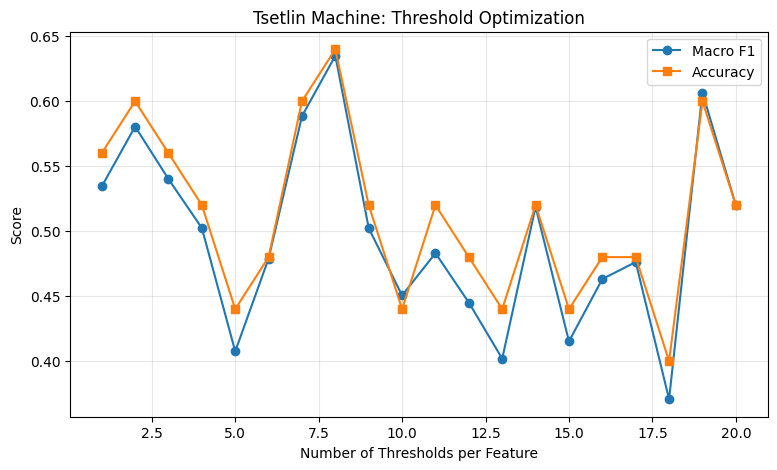

In [33]:
import matplotlib.pyplot as plt

results_sorted = results_df.sort_values("n_thresholds")

plt.figure(figsize=(9, 5))

plt.plot(
    results_sorted["n_thresholds"],
    results_sorted["macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    results_sorted["n_thresholds"],
    results_sorted["accuracy"],
    marker="s",
    label="Accuracy"
)

plt.xlabel("Number of Thresholds per Feature")
plt.ylabel("Score")
plt.title("Tsetlin Machine: Threshold Optimization")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [34]:
X_train_full = np.vstack([ X_train_np,X_validation_np])
y_train_full = np.concatenate([y_train_enc,y_validation_enc])

# Recalculate thresholds using ALL training data
final_thresholds = compute_thresholds( X_train_full, best_n_thresholds)
X_train_full_bin = threshold_binarize(X_train_full, final_thresholds)
X_test_bin = threshold_binarize(X_test_np, final_thresholds)

print("Final training shape:", X_train_full_bin.shape)
print("Final test shape:", X_test_bin.shape)

final_tm = MultiClassTsetlinMachine(1000,50,5.0)

final_tm.fit( X_train_full_bin, y_train_full, epochs=100)

test_predictions = final_tm.predict(X_test_bin)

Final training shape: (100, 80)
Final test shape: (50, 80)


In [35]:
print("Test Accuracy:",accuracy_score(y_test_enc, test_predictions))
print("Test Macro F1:", f1_score( y_test_enc, test_predictions, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test_enc,test_predictions,target_names=label_encoder.classes_ ))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc,test_predictions))

Test Accuracy: 0.54
Test Macro F1: 0.5472665621272432

Classification Report:
              precision    recall  f1-score   support

         DCM       0.78      0.70      0.74        10
         HCM       0.27      0.30      0.29        10
        MINF       0.71      0.50      0.59        10
         NOR       0.33      0.40      0.36        10
          RV       0.73      0.80      0.76        10

    accuracy                           0.54        50
   macro avg       0.57      0.54      0.55        50
weighted avg       0.57      0.54      0.55        50


Confusion Matrix:
[[7 2 1 0 0]
 [0 3 1 6 0]
 [2 3 5 0 0]
 [0 3 0 4 3]
 [0 0 0 2 8]]
